In [2]:
import torch
import numpy as np
import pandas as pd
import json
from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


In [3]:
# Load balanced master dataset
df = pd.read_csv('../data/processed/master_dataset_balanced.csv')

# Load label maps
with open('../data/processed/label2id.json') as f:
    label2id = json.load(f)
with open('../data/processed/id2label.json') as f:
    id2label = json.load(f)

# Convert id2label keys back to integers
id2label = {int(k): v for k, v in id2label.items()}

NUM_LABELS = len(label2id)
print(f"Total samples : {len(df)}")
print(f"Num classes   : {NUM_LABELS}")
print(f"\nLabel mapping :")
for label, idx in sorted(label2id.items()):
    count = (df['label'] == label).sum()
    print(f"  {idx:2d} → {label:<25} ({count} samples)")

Total samples : 5386
Num classes   : 12

Label mapping :
   0 → FR                        (2000 samples)
   1 → NFR_Legal                 (249 samples)
   2 → NFR_LookAndFeel           (300 samples)
   3 → NFR_Maintainability       (300 samples)
   4 → NFR_Operational           (500 samples)
   5 → NFR_Other                 (300 samples)
   6 → NFR_Performance           (300 samples)
   7 → NFR_Portability           (300 samples)
   8 → NFR_Reliability           (300 samples)
   9 → NFR_Scalability           (300 samples)
  10 → NFR_Security              (278 samples)
  11 → NFR_Usability             (259 samples)


In [4]:
# Stratified split to preserve class distribution
# 80% train | 10% validation | 10% test
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f"Train samples      : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")

# Verify class distribution is preserved
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts())

# Save test set separately — never touched during training
test_df.to_csv('../data/processed/test_set.csv', index=False)
print("\nTest set saved to test_set.csv")

Train samples      : 4308
Validation samples : 539
Test samples       : 539

Train label distribution:
label
FR                     1600
NFR_Operational         400
NFR_Other               240
NFR_Maintainability     240
NFR_Performance         240
NFR_Reliability         240
NFR_Scalability         240
NFR_LookAndFeel         240
NFR_Portability         240
NFR_Security            222
NFR_Usability           207
NFR_Legal               199
Name: count, dtype: int64

Test set saved to test_set.csv


In [5]:
# Load BERT tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128  # covers 95%+ of requirement sentences

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label_id']].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[['text', 'label_id']].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df[['text', 'label_id']].reset_index(drop=True))

# Rename label_id to labels (required by HuggingFace Trainer)
train_dataset = train_dataset.rename_column('label_id', 'labels')
val_dataset   = val_dataset.rename_column('label_id', 'labels')
test_dataset  = test_dataset.rename_column('label_id', 'labels')

# Tokenize
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset   = val_dataset.map(tokenize_batch, batched=True)
test_dataset  = test_dataset.map(tokenize_batch, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
train_dataset.set_format(type='torch', columns=cols)
val_dataset.set_format(type='torch', columns=cols)
test_dataset.set_format(type='torch', columns=cols)

print(f"Tokenization complete")
print(f"   Train : {len(train_dataset)} samples")
print(f"   Val   : {len(val_dataset)} samples")
print(f"   Test  : {len(test_dataset)} samples")

Tokenizing datasets...


Map:   0%|          | 0/4308 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Tokenization complete
   Train : 4308 samples
   Val   : 539 samples
   Test  : 539 samples


In [6]:
# Load model
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Model loaded to      : {device}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters     : 109,491,468
Trainable parameters : 109,491,468
Model loaded to      : cuda


In [7]:
# Training configuration
# Settings are tuned for RTX 4060 Laptop (8.6GB VRAM)
MODEL_NAME = 'bert-large-uncased'
BATCH_SIZE    = 8    # safe for 8.6GB — increase to 32 if no OOM error
EPOCHS        = 10
LEARNING_RATE = 2e-5  # standard BERT fine-tuning rate
WARMUP_RATIO  = 0.1   # 10% warmup steps

training_args = TrainingArguments(
    output_dir                  = '../models/bert_requirements',
    num_train_epochs            = EPOCHS,
    lr_scheduler_type = 'cosine',  # smoother decay
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_dir                 = '../models/logs',
    logging_steps               = 50,
    fp16                        = True,   # RTX 4060 supports fp16 — halves VRAM usage
    dataloader_num_workers      = 2,
    report_to                   = 'none', # disable wandb
    save_total_limit            = 2,      # keep only best 2 checkpoints
    seed                        = 42,
)

print("Training configuration:")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  fp16          : True (VRAM optimized)")
print(f"  Warmup ratio  : {WARMUP_RATIO}")

Training configuration:
  Batch size    : 8
  Epochs        : 10
  Learning rate : 2e-05
  fp16          : True (VRAM optimized)
  Warmup ratio  : 0.1


In [8]:
# Define metrics computation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        'f1_macro'   : f1_score(labels, predictions, average='macro',    zero_division=0),
        'f1_weighted': f1_score(labels, predictions, average='weighted', zero_division=0),
        'precision'  : precision_score(labels, predictions, average='macro', zero_division=0),
        'recall'     : recall_score(labels, predictions, average='macro',    zero_division=0),
    }

In [9]:
# Initialize Trainer
from torch import nn

# Calculate class weights — inverse frequency
class_counts = df['label_id'].value_counts().sort_index()
total = len(df)

class_weights = {
    'FR'                  : 1.0,
    'NFR_Other'           : 0.4,   # raise to 0.8
    'NFR_Legal'           : 1.5,
    'NFR_Usability'       : 2.0,
    'NFR_Security'        : 2.0,
    'NFR_Operational'     : 1.0,   # boost
    'NFR_Performance'     : 1.5,
    'NFR_Reliability'     : 1.5,
    'NFR_Maintainability' : 1.5,
    'NFR_LookAndFeel'     : 1.5,
    'NFR_Portability'     : 1.5,
    'NFR_Scalability'     : 1.5,
}

weights_list = [0.0] * len(class_weights)

for label, weight in class_weights.items():
    label_idx = label2id[label]  
    weights_list[label_idx] = weight

class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# Custom trainer with weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("Starting training...")

train_result = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
).train()

print(f"\nTraining complete!")
print(f"   Total steps    : {train_result.global_step}")
print(f"   Training loss  : {train_result.training_loss:.4f}")
print(f"   Time taken     : {train_result.metrics['train_runtime']/60:.1f} minutes")

Starting training...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Precision,Recall
1,1.486100,1.253642,0.545803,0.633942,0.597401,0.570527
2,0.477200,0.488836,0.790476,0.810488,0.779024,0.809411
3,0.259100,0.500784,0.849127,0.862143,0.846794,0.867524
4,0.126800,0.428259,0.858361,0.873026,0.864116,0.883637
5,0.069700,0.441955,0.885884,0.892136,0.882994,0.894319
6,0.045500,0.522467,0.878498,0.885388,0.874655,0.884974
7,0.009500,0.545689,0.885878,0.886991,0.868627,0.906653
8,0.014600,0.531697,0.887108,0.891995,0.876540,0.900264
9,0.007500,0.528398,0.889916,0.895230,0.882171,0.899559
10,0.041100,0.532760,0.889916,0.895230,0.882171,0.899559



Training complete!
   Total steps    : 5390
   Training loss  : 0.3151
   Time taken     : 11.2 minutes


In [10]:
# Evaluate on validation set
print("Evaluating on held-out test set...")
predictions = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
).predict(test_dataset)
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Full classification report
label_names = [id2label[i] for i in range(NUM_LABELS)]
print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(labels, preds, target_names=label_names, digits=4))

# Save metrics
test_f1 = f1_score(labels, preds, average='macro')
print(f"\nTest F1 (macro): {test_f1:.4f}")

Evaluating on held-out test set...



=== CLASSIFICATION REPORT ===

                     precision    recall  f1-score   support

                 FR     0.8990    0.8900    0.8945       200
          NFR_Legal     0.8750    0.8400    0.8571        25
    NFR_LookAndFeel     0.9062    0.9667    0.9355        30
NFR_Maintainability     0.9091    1.0000    0.9524        30
    NFR_Operational     0.8868    0.9400    0.9126        50
          NFR_Other     0.7273    0.5333    0.6154        30
    NFR_Performance     0.8824    1.0000    0.9375        30
    NFR_Portability     0.9677    1.0000    0.9836        30
    NFR_Reliability     0.8750    0.9333    0.9032        30
    NFR_Scalability     1.0000    1.0000    1.0000        30
       NFR_Security     0.8077    0.7500    0.7778        28
      NFR_Usability     0.7917    0.7308    0.7600        26

           accuracy                         0.8887       539
          macro avg     0.8773    0.8820    0.8775       539
       weighted avg     0.8854    0.8887    0.8856 

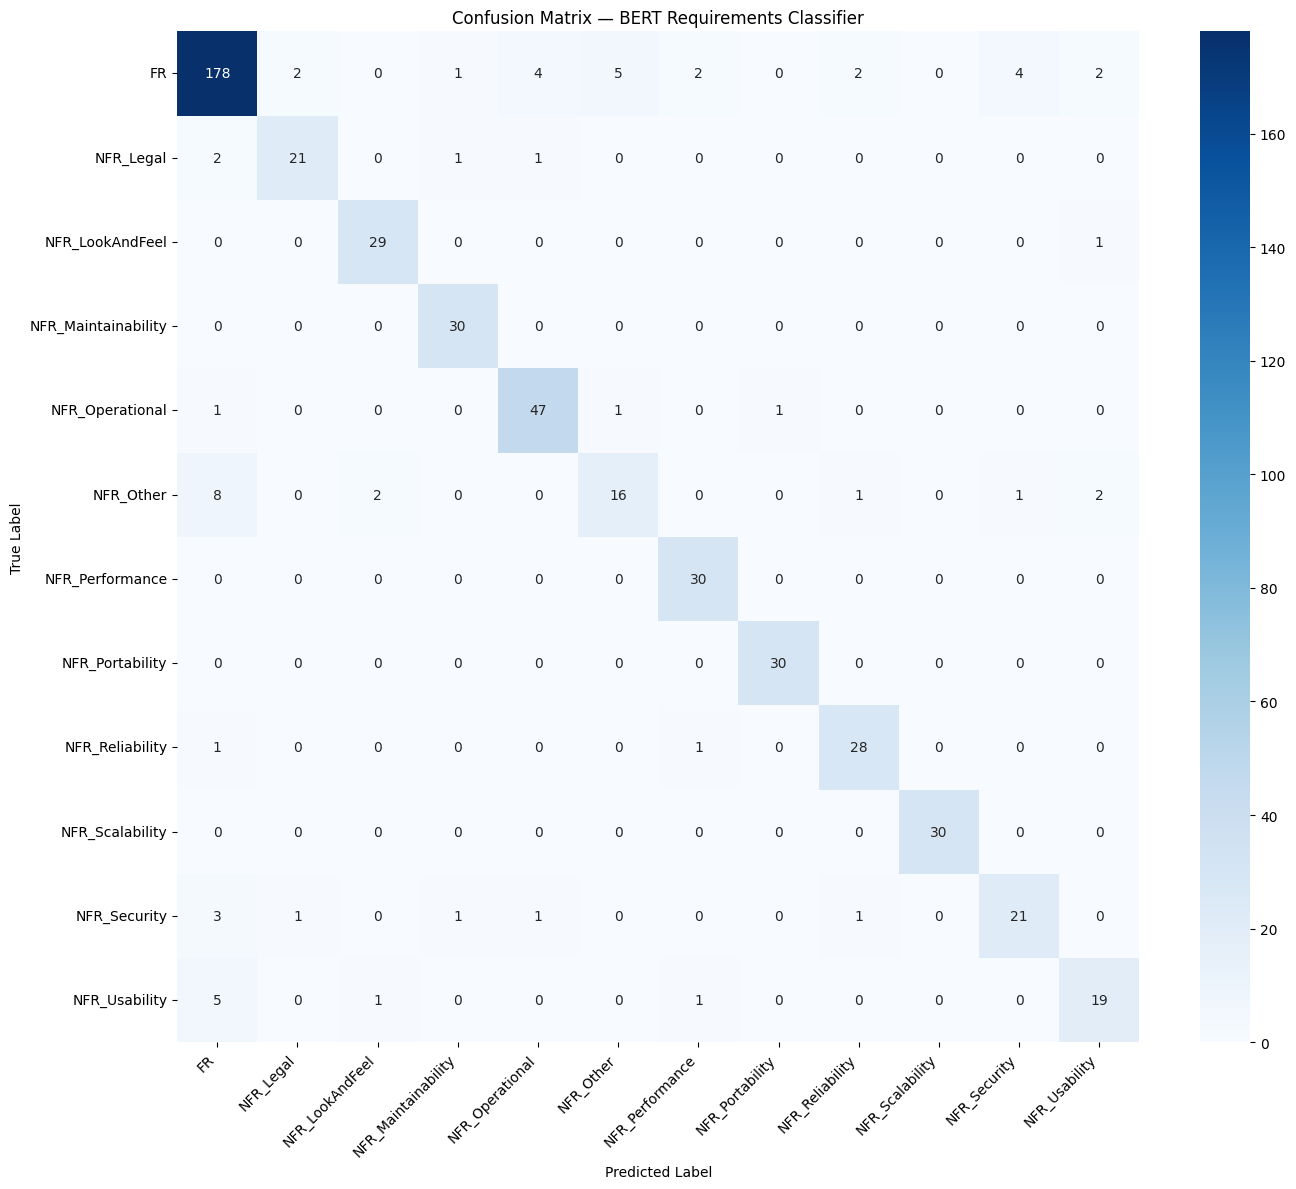

Saved confusion_matrix.png


In [11]:
# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix — BERT Requirements Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

In [12]:
# Save model + tokenizer
model_path = '../models/bert_requirements_final'
WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
).save_model(model_path)
tokenizer.save_pretrained(model_path)

# Save label maps alongside the model
with open(f'{model_path}/label2id.json', 'w') as f:
    json.dump(label2id, f, indent=2)
with open(f'{model_path}/id2label.json', 'w') as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, indent=2)

print(f"Model saved to {model_path}")
print(f"\nFiles saved:")
for f in os.listdir(model_path):
    size = os.path.getsize(f'{model_path}/{f}') / 1e6
    print(f"  {f:<40} {size:.1f} MB")

Model saved to ../models/bert_requirements_final

Files saved:
  config.json                              0.0 MB
  id2label.json                            0.0 MB
  label2id.json                            0.0 MB
  model.safetensors                        438.0 MB
  special_tokens_map.json                  0.0 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB
  vocab.txt                                0.3 MB
